In [2]:
from pathlib import Path

"""
Replace with your desired directories
"""

from utility import repo_root

FIG_DIR = Path("/Users/zach/2025_RA/matthias/final images/2_wake_vs_sleep_signal")
FIG_DIR.mkdir(exist_ok=True, parents=True)
BIDS_DIR = Path("/Users/zach/2025_RA/matthias/bids_sleepmreye")
CONFIG_DIR = Path(repo_root() / "sleepmreye" / "designs")

In [3]:
from mreyemove.analysis.glm.cli import construct_desc
from mreyemove.analysis.glm.config import GLMConfig
from SleepMReye.sleepmreye.sleep_mrio import SleepMRIO

mrio = SleepMRIO(
    bids_root=BIDS_DIR,
    data_dir=BIDS_DIR / "derivatives" / "fmriprep",
    tr=2.1,
    task="sleep",
    desc_add="clean",
    load_eog=False
)

config = GLMConfig.from_yaml(CONFIG_DIR / "original_sleep.yml")
desc_add = construct_desc(dataset=mrio, config=config)
desc_add = f"{desc_add}-{config.second_level.method}"
print(desc_add)


clean-original-sleep-flame


In [4]:
import numpy as np

def create_blocks(arr, trim: int):
    # Get indices where values are not NaN
    valid = ~np.isnan(arr)
    # Find contiguous blocks
    changes = np.diff(valid.astype(int))
    block_starts = np.where(changes == 1)[0] + 1
    block_ends = np.where(changes == -1)[0] + 1
    
    # Handle edge cases where array starts/ends with valid values
    if valid[0]:
        block_starts = np.concatenate([[0], block_starts])
    if valid[-1]:
        block_ends = np.concatenate([block_ends, [len(arr)]])
    
    blocks = [arr[s+trim:e-trim] for s, e in zip(block_starts, block_ends) 
          if (e - trim) - (s + trim) > 0]
    return blocks


def permute_labels(blocks):
    labels = [l for _, l in blocks]
    np.random.shuffle(labels)
    return [(b, l) for (b, _), l in zip(blocks, labels)]


In [5]:
l1 = "W"
l2 = "S"

subject_blocks = {}
for subject in mrio.subjects:
    blocks = []
    
    # For each run, get contiguous sleep and wake blocks,
    # trimming the edge TRs off
    for _, run, run_df in mrio.iter_run_events(subject=subject):
        eye_signal = run_df["mreyemove"]
        wake = np.full_like(eye_signal, np.nan)
        wake[run_df[l1]] = eye_signal[run_df[l1]]
        for block in create_blocks(wake, trim=0):
            blocks.append((block, l1))
        
        sleep = np.full_like(eye_signal, np.nan)
        sleep[run_df[l2]] = eye_signal[run_df[l2]]
        for block in create_blocks(sleep, trim=0):
            blocks.append((block, l2))
    
    subject_blocks[subject] = blocks
        
subject_blocks = {
    s: blocks for s, blocks in subject_blocks.items()
    if any(l == l2 for _, l in blocks)  
}
    

In [6]:
from scipy.stats import ttest_1samp
import numpy as np 

def compute_statistic(blocks, stat, l1, l2):
    """
    Compute statistic per subject
    Find the difference in descriptors for each state using all 
    contiguous state blocks across runs 
    Parameters
    ----------
    blocks
    stat

    Returns
    -------

    """
    wake_vals = np.concatenate([b for b, l in blocks if l == l1])
    sleep_vals = np.concatenate([b for b, l in blocks if l == l2])
    if stat == "mean":
        return np.mean(wake_vals) - np.mean(sleep_vals)
    elif stat == "std":
        return np.std(wake_vals) - np.std(sleep_vals)
    elif stat == "count":
        return len(wake_vals) - len(sleep_vals)
    elif stat == "median":
        return np.median(wake_vals) - np.median(sleep_vals)
    elif stat == "iqr":
        return np.percentile(wake_vals, 75) - np.percentile(sleep_vals, 25)

def permutation_test(subject_blocks, stat, n_permutations=10000):
    subjects = list(subject_blocks.keys())
    
    subj_zs = []
    subj_means = []
    for subject in subjects:
        subj_null_distribution = []
        for _ in range(n_permutations):
            perm_stats = np.array([
                compute_statistic(permute_labels(subject_blocks[subject]), stat, l1, l2) 
            ])
            subj_null_distribution.append(np.mean(perm_stats))
        shuffled_mean = np.mean(subj_null_distribution)
        shuffled_std = np.std(subj_null_distribution)
        observed_mean = compute_statistic(subject_blocks[subject], stat, l1, l2)
        
        subj_z = (observed_mean - shuffled_mean) / shuffled_std
        subj_zs.append(subj_z)
        subj_means.append(observed_mean)
    return np.mean(subj_zs), subj_zs, np.mean(subj_means)

print("Count")
mean_zs, zs, obs  = permutation_test(subject_blocks, stat="count", n_permutations=10000)
print(f"obs mean: {obs}, mean z: {mean_zs}, {ttest_1samp(zs, 0, alternative='two-sided')}")

print("Mean")
mean_zs, zs, obs  = permutation_test(subject_blocks, stat="mean", n_permutations=10000)
print(f"obs mean: {obs}, mean z: {mean_zs}, {ttest_1samp(zs, 0, alternative='two-sided')}")


print("Std")
mean_zs, zs, obs  = permutation_test(subject_blocks, stat="std", n_permutations=10000)
print(f"obs mean: {obs}, mean z: {mean_zs}, {ttest_1samp(zs, 0, alternative='two-sided')}")



Count
obs mean: -116.0, mean z: -0.45581108463616166, TtestResult(statistic=-1.437520331908536, pvalue=0.16091973848365634, df=30)
Mean
obs mean: -0.001786214305963365, mean z: -0.15492099399274753, TtestResult(statistic=-0.5664593996223195, pvalue=0.5752952154015432, df=30)
Std
obs mean: -0.000871204474283119, mean z: 0.17889604360186645, TtestResult(statistic=0.7131801978582952, pvalue=0.48124557938705503, df=30)


In [7]:
import pandas as pd 
import numpy as np 

def compute_stat_df(
    df: pd.DataFrame,
    state_cols: list[str],
    subject_col: str = "subject",
    run_col: str = "run",
) -> pd.DataFrame:
    """

    Parameters
    ----------
    df : pd.DataFrame
        Long-format events dataframe with one row per TR, containing
        subject_col, run_col, and the state mask columns.
    state_cols : list[str]
        Names of boolean state mask columns.
    subject_col, run_col : str
        Column names for grouping.

    Returns
    -------
    pd.DataFrame
        One row per (subject, run, state) with columns:
        - n_trs_total: total TRs in the run
        - n_trs_original: TRs where original mask is True
        - n_trs_eroded: TRs where eroded mask is True
        - n_trs_lost: TRs lost to erosion
        - pct_lost_of_run: lost TRs as % of run length
        - pct_lost_of_state: lost TRs as % of original state coverage
        - n_transitions: number of state changes in the run
    """
    rows = []
    for (subj, run), group in df.groupby([subject_col, run_col], sort=False):
        n_total = len(group)
        for state in state_cols:
            mask = group[state].to_numpy()
            signal = group["mreyemove"][mask]
            n_orig = int(mask.sum())
            rows.append({
                subject_col: subj,
                run_col: run,
                "state": state,
                "n_trs_total": n_total,
                "n_trs": n_orig,
                "mean_signal": np.mean(signal),
                "std_signal": np.std(signal),
            })
    return pd.DataFrame(rows)

In [8]:
df = mrio.events
state = ["W", "S"]
stat_df = compute_stat_df(df, state_cols=state)


mean_signal
         median       q25       q75
state                              
S      0.007166  0.004378  0.011218
W      0.006757  0.004649  0.009915


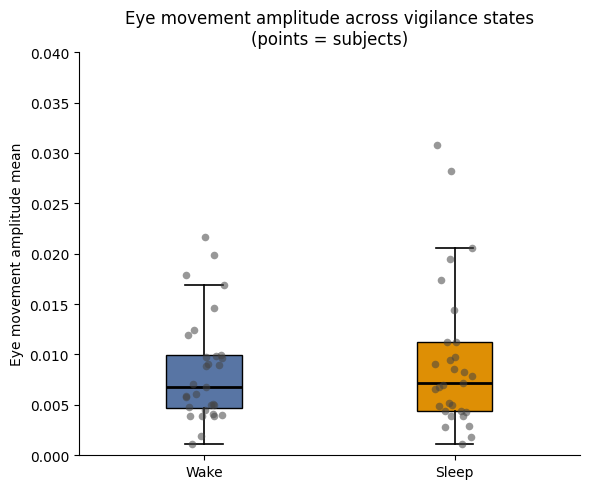

std_signal
         median       q25       q75
state                              
S      0.005984  0.002998  0.009592
W      0.006637  0.003748  0.010739


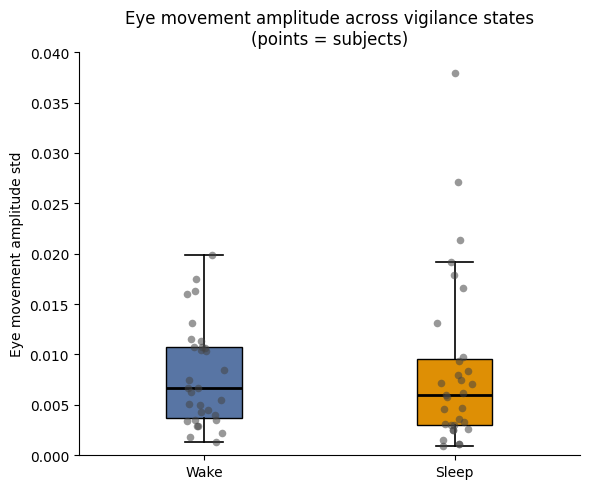

n_trs
       median         q25         q75
state                                
S       230.0  140.428571  290.416667
W       197.0  104.333333  285.571429


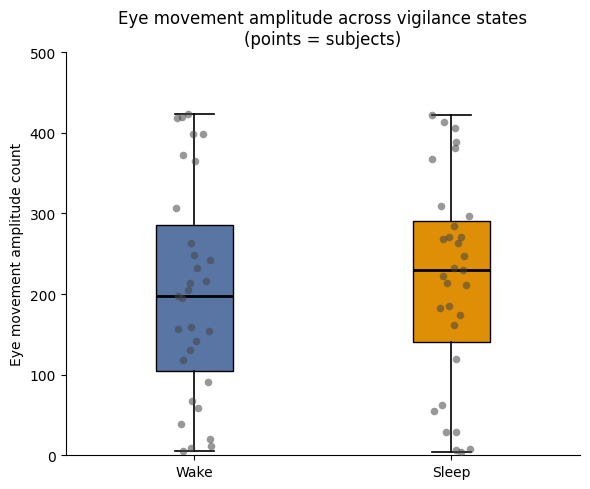

In [9]:

import matplotlib.pyplot as plt
import numpy as np

def get_state_values(subject_blocks, label, stat, agg):
    subjects = list(subject_blocks.keys())
    result = []
    for s in subjects:
        blocks = [b for b, l in subject_blocks[s] if l == label]
        if len(blocks) > 0:
            if agg == "concat":
                result.append((s, stat(np.concatenate(blocks))))
            elif agg == "mean":
                # Have to do comprehension in case function is not element-wise e.g., len
                result.append((s, np.mean([stat(b) for b in blocks])))   
        else:
            result.append((s, np.nan))
    return result  # list of (subject, value) tuples, nan if no data


states = {"W": "Wake", "S": "Sleep"}
colors = {"W": "#5875a4ff", "S": "#de8f05ff"}

ylims = [
    (0,0.04),
    (0,0.04),
    (0, 500),
]

agg = "concat"

for i, (stat, desc) in enumerate(zip(["mean_signal", "std_signal", "n_trs"], ["mean", "std", "count"])):
    
    per_subject = (stat_df.groupby(["subject", "state"])[stat]
               .mean()  # mean across runs per subject
               .reset_index())
    
    print(stat)
    summary = per_subject.groupby("state")[stat].agg(
        median="median",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
    )
    print(summary)
    
    groups = [per_subject[per_subject["state"] == state][stat] for state in states]

    fig, ax = plt.subplots(figsize=(6, 5))
    
    # Boxplots
    bp = ax.boxplot(
        groups,
        # [np.array([v for v in state_values[s].values() if not np.isnan(v)]) for s in states],
        positions=range(2),
        widths=0.3,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color='black', linewidth=2),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
        flierprops=dict(marker='o', markersize=4, alpha=0.5),
        zorder=2
    )
    
    for patch, label in zip(bp['boxes'], states.keys()):
        patch.set_facecolor(colors[label])
        patch.set_alpha(1)

    # Jittered subject points
    for j, state in enumerate(states.keys()):
        valid = np.array([v for v in groups[j] if not np.isnan(v)])
        jitter = np.random.uniform(-0.08, 0.08, len(valid))
        ax.scatter(
            np.full(len(valid), j) + jitter,
            valid,
            color="#4444448c", alpha=0.55, s=30, zorder=3,
            edgecolors='white', linewidths=0
        )
    
    ax.set_xticks(range(2))
    ax.set_xticklabels(states.values())
    ax.set_ylabel(f"Eye movement amplitude {desc}")
    ax.set_title("Eye movement amplitude across vigilance states\n(points = subjects)")
    ax.set_ylim(ylims[i])
    ax.spines[["top", "right"]].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    fig.savefig(FIG_DIR / f"{desc}_amplitude_states.svg", dpi=300)


